***Step 1: Data Collection***

*Import Libraries*

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings

pd.set_option('display.max_columns', None)

# Visualization style

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

*Load Dataset*

In [2]:
# Load dataset

df = pd.read_csv("student_performance.csv")

*Display First Records*

In [3]:
# Display the first five rows

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


*Dataset Shape*

In [4]:
# Display dataset dimensions

df.shape

(1000000, 6)

*Dataset Information*

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


*Missing Values*

In [6]:
# Check missing values

df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


*Duplicate Records*

In [7]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

*Descriptive Statistics*

In [8]:
# Generate descriptive statistics

df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


*Display Column Names*

In [9]:
# Display all column names

df.columns

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

***Step 2: Data Preprocessing***

*Check Data Types*

In [14]:
# Check data types

df.dtypes

,0
student_id,int64
weekly_self_study_hours,float64
attendance_percentage,float64
class_participation,float64
total_score,float64
grade,object


*Encoding*

In [16]:
# Encoding

# This dataset contains only numerical features.
# Therefore, encoding is not required.

print("No categorical variables found.")
print("Encoding is not required for this dataset.")

No categorical variables found.
Encoding is not required for this dataset.


*Feature Selection*

In [10]:
# Select input features

X = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation"
    ]
]

# Select target variable

y = df["total_score"]

*Display Features*

In [11]:
# Display selected features

X.head()

,weekly_self_study_hours,attendance_percentage,class_participation
0,18.5,95.6,3.8
1,14.0,80.0,2.5
2,19.5,86.3,5.3
3,25.7,70.2,7.0
4,13.4,81.9,6.9


*Display Target*

In [12]:
# Display target variable

y.head()

,total_score
0,97.9
1,83.9
2,100.0
3,100.0
4,92.0


*Train-Test Split*

In [13]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (800000, 3)
Testing Set: (200000, 3)


***Step 3: Exploratory Data Analysis***

*Target Distribution*

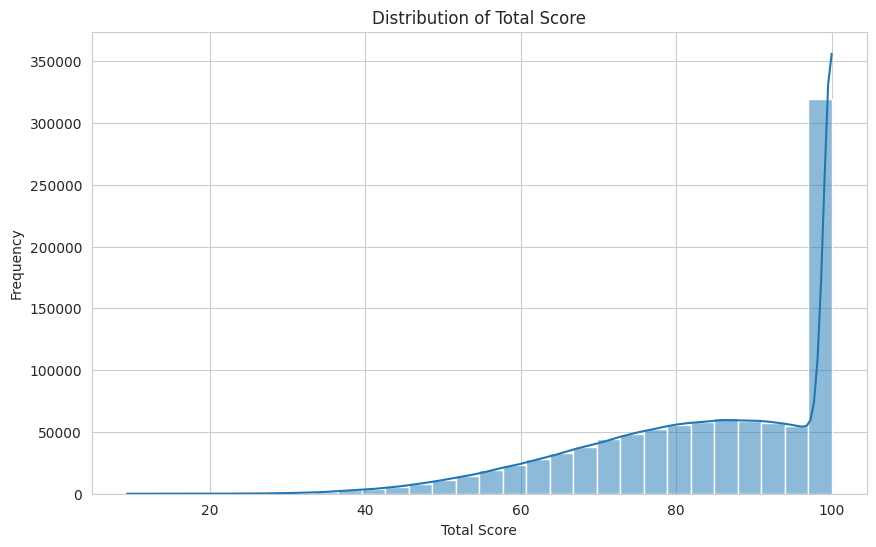

In [17]:
# Distribution of total score

plt.figure(figsize=(10,6))

sns.histplot(
    df["total_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")

plt.show()

*Study Hours vs Total Score*

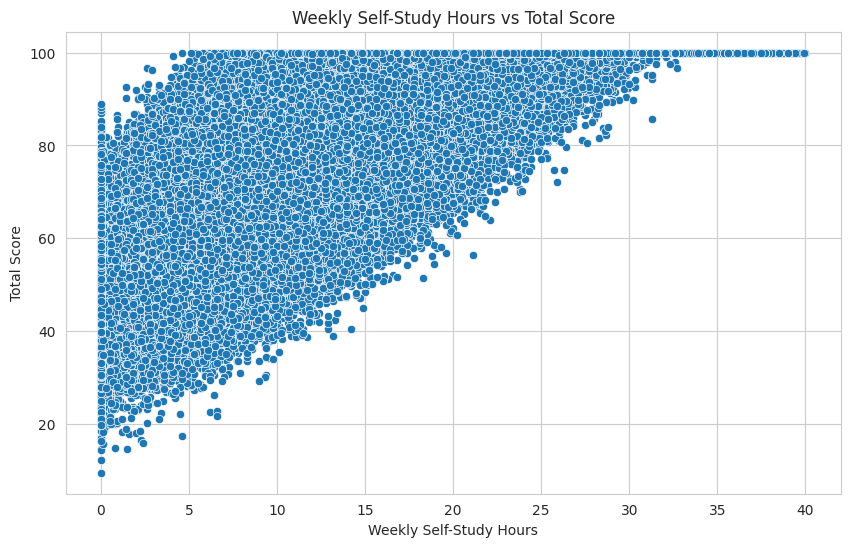

In [18]:
# Relationship between weekly self-study hours and total score

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="weekly_self_study_hours",
    y="total_score",
    data=df
)

plt.title("Weekly Self-Study Hours vs Total Score")
plt.xlabel("Weekly Self-Study Hours")
plt.ylabel("Total Score")

plt.show()

*Attendance vs Total Score*

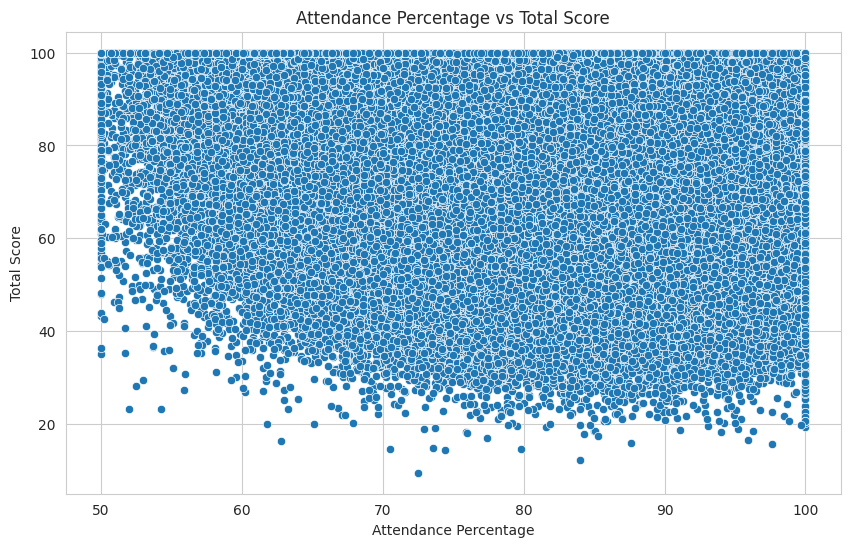

In [19]:
# Relationship between attendance percentage and total score

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="attendance_percentage",
    y="total_score",
    data=df
)

plt.title("Attendance Percentage vs Total Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Total Score")

plt.show()

*Correlation Matrix*

In [21]:
# Calculate correlation matrix

corr = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score"
    ]
].corr()

corr

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.001008,0.001244,0.812241
attendance_percentage,-0.001008,1.000000,-0.000043,-0.001014
class_participation,0.001244,-0.000043,1.000000,0.000684
total_score,0.812241,-0.001014,0.000684,1.000000


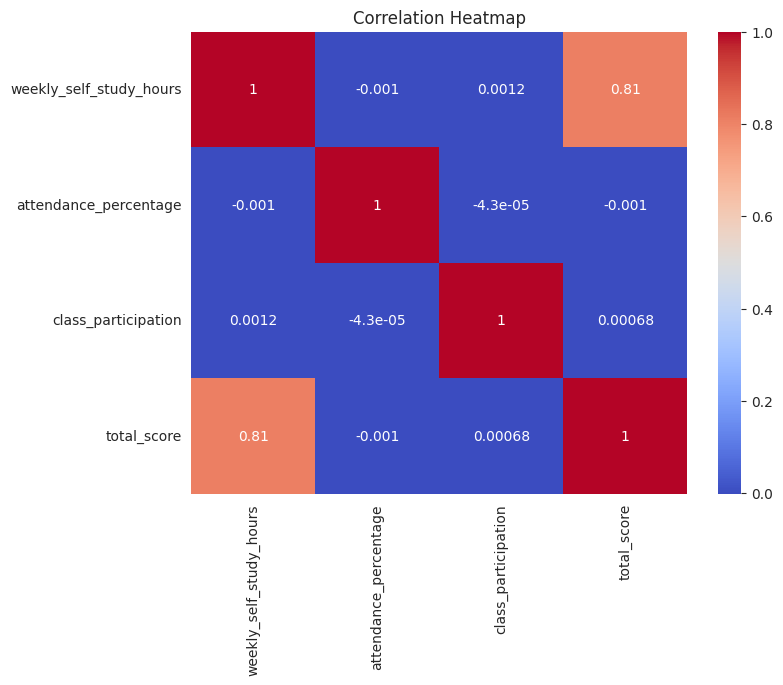

In [22]:
# Create correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

***Step 4: Model Building***

*Linear Regression*

In [23]:
# Build Linear Regression model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

*Linear Regression Predictions*

In [24]:
# Predict using Linear Regression

lr_predictions = lr_model.predict(X_test)

*Decision Tree*

In [25]:
# Build Decision Tree Regressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

*Decision Tree Predictions*

In [26]:
# Predict using Decision Tree

dt_predictions = dt_model.predict(X_test)

*Random Forest*

In [27]:
# Build Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

*Random Forest Predictions*

In [28]:
# Predict using Random Forest

rf_predictions = rf_model.predict(X_test)

***Step 5: Model Evaluation***

*Linear Regression Evaluation*

In [29]:
# Evaluate Linear Regression

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression Performance
MAE: 7.16
RMSE: 9.00
R² Score: 0.6600


*Decision Tree Evaluation*

In [30]:
# Evaluate Decision Tree

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print(f"MAE: {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R² Score: {dt_r2:.4f}")

Decision Tree Performance
MAE: 8.37
RMSE: 11.63
R² Score: 0.4319


*Random Forest Evaluation*

In [31]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Performance
MAE: 6.68
RMSE: 9.06
R² Score: 0.6549


*Model Comparison*

In [32]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,7.161333,8.996401,0.660043
1,Decision Tree,8.368287,11.629536,0.431917
2,Random Forest,6.681405,9.063711,0.654936


*Model Comparison Visualization*

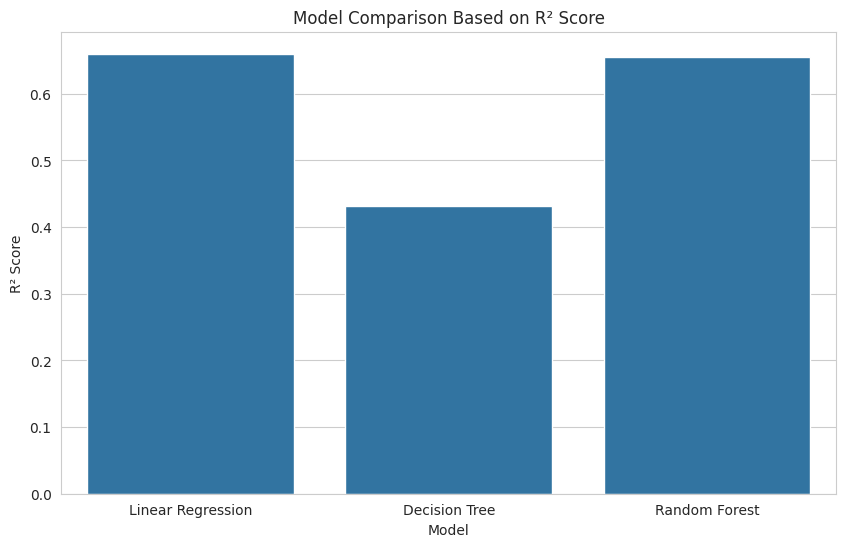

In [33]:
# Visualize model comparison using R² Score

plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R² Score",
    data=results
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

*Feature Importance*

In [34]:
# Get feature importance from Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,weekly_self_study_hours,0.763292
1,attendance_percentage,0.136999
2,class_participation,0.099709


*Feature Importance Visualization*

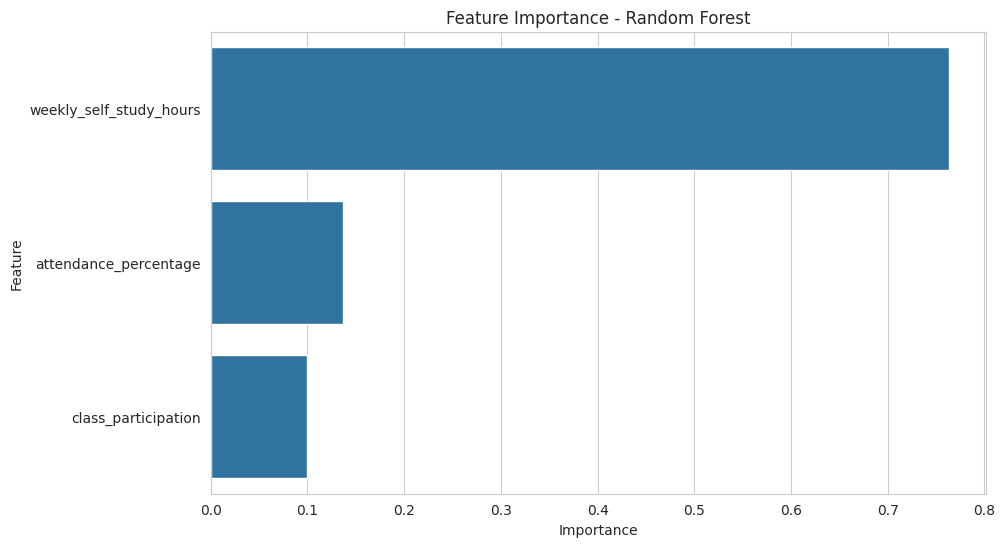

In [35]:
# Visualize feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

*Actual vs Predicted*

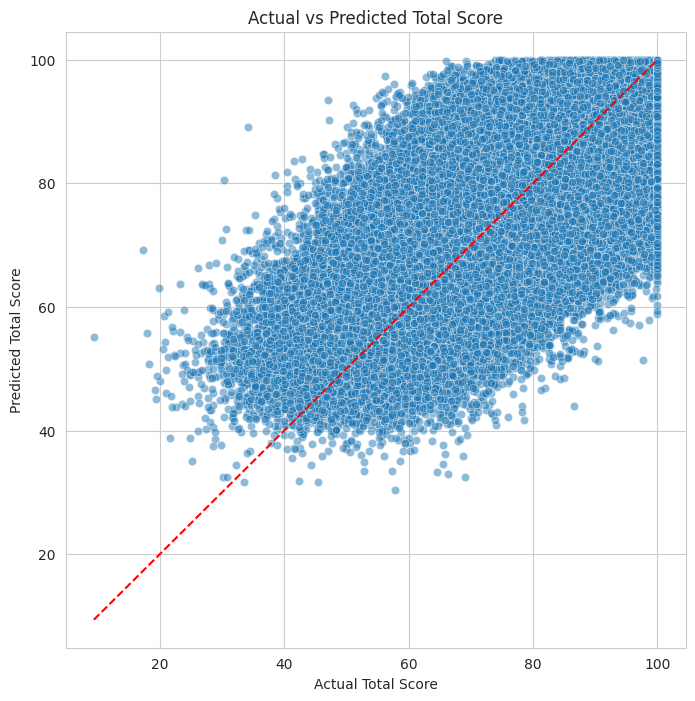

In [38]:
# Actual vs Predicted Values

plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_test,
    y=rf_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Actual vs Predicted Total Score")
plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")

plt.show()

***Final Conclusion***

In [39]:
# Final project conclusion

print("""
Final Conclusion

This project developed and evaluated three machine learning models to predict
student performance based on study-related factors.

The following models were implemented:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Model performance was evaluated using MAE, RMSE, and R² Score.

Results Summary:

• Linear Regression achieved the highest R² Score (0.6600), indicating that it
  explained approximately 66% of the variation in students' total scores.

• Random Forest achieved the lowest MAE (6.68), making it the most accurate
  model in terms of average prediction error.

• Decision Tree produced the weakest performance, with the highest prediction
  error and the lowest R² Score.

Key Insights:

1. Weekly self-study hours, attendance percentage, and class participation
   are important factors influencing student performance.

2. Correlation analysis showed positive relationships between the selected
   features and the target variable.

3. Both Linear Regression and Random Forest demonstrated reliable predictive
   performance, while Decision Tree was less effective for this dataset.

4. The Actual vs Predicted visualization showed that the models captured the
   overall trend of student performance, although some prediction errors
   remained due to factors not included in the dataset.

Overall, this project successfully demonstrated the complete machine learning
workflow, including data collection, preprocessing, exploratory data analysis,
model development, evaluation, and interpretation of results.
""")



Final Conclusion

This project developed and evaluated three machine learning models to predict
student performance based on study-related factors.

The following models were implemented:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Model performance was evaluated using MAE, RMSE, and R² Score.

Results Summary:

• Linear Regression achieved the highest R² Score (0.6600), indicating that it
  explained approximately 66% of the variation in students' total scores.

• Random Forest achieved the lowest MAE (6.68), making it the most accurate
  model in terms of average prediction error.

• Decision Tree produced the weakest performance, with the highest prediction
  error and the lowest R² Score.

Key Insights:

1. Weekly self-study hours, attendance percentage, and class participation
   are important factors influencing student performance.

2. Correlation analysis showed positive relationships between the selected
   features and the target variable.

3.